In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from ridge_regression_utils import WAVEFORM_LABELS, FEAT_LABELS

warnings.filterwarnings('ignore')

In [13]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = os.path.join(SPE1_PICKLE_ROOT, 'ridge_regression_pickles')
FDR_Q            = 0.05
MIN_CELLS        = 2    # minimum cells needed to run population test for a given target

In [14]:
# ── Load all cell pickles ──────────────────────────────────────────────────────
files = sorted(f for f in os.listdir(RIDGE_PICKLE_DIR) if f.endswith('_ridge_results.pkl'))
cell_ids = [f.replace('_ridge_results.pkl', '') for f in files]

all_results = {}
for fname, cid in zip(files, cell_ids):
    with open(os.path.join(RIDGE_PICKLE_DIR, fname), 'rb') as f:
        all_results[cid] = pickle.load(f)

# Derive shared structure from first cell
first = next(iter(all_results.values()))
target_names  = list(first.keys())
predictor_sets = list(first[target_names[0]].keys())
waveform_labels = WAVEFORM_LABELS

feat_keys   = ['lfp_amp', 'lfp_std', 'gamma_auc', 'exponent', 'theta_auc']
feat_labels = FEAT_LABELS
target_labels = (
    [f'Pre {l}'    for l in feat_labels] +
    [f'Pre−BL {l}' for l in feat_labels] +
    [f'Δ {l}'      for l in feat_labels]
)

print(f'Loaded {len(all_results)} cells')
print(f'Targets ({len(target_names)}): {target_names}')
print(f'Predictor sets: {predictor_sets}')

Loaded 38 cells
Targets (15): ['pre_lfp_amp', 'pre_lfp_std', 'pre_gamma_auc', 'pre_exponent', 'pre_theta_auc', 'prebc_lfp_amp', 'prebc_lfp_std', 'prebc_gamma_auc', 'prebc_exponent', 'prebc_theta_auc', 'delta_lfp_amp', 'delta_lfp_std', 'delta_gamma_auc', 'delta_exponent', 'delta_theta_auc']
Predictor sets: ['Waveform only', 'Log ISI only', 'Waveform + Log ISI']


In [15]:
# ── Aggregate R² and betas across cells ───────────────────────────────────────
# r2_pop[target][pset]   → array of CV R² across cells (NaN if not available)
# beta_pop[target][feat] → array of beta weights across cells (Waveform only model)
# sig_pop[target][pset]  → bool array: was model FDR-significant in that cell?

r2_pop   = {tn: {pn: [] for pn in predictor_sets} for tn in target_names}
sig_pop  = {tn: {pn: [] for pn in predictor_sets} for tn in target_names}
beta_pop = {tn: {wl: [] for wl in waveform_labels} for tn in target_names}

for cid, res in all_results.items():
    for tn in target_names:
        for pn in predictor_sets:
            entry = res.get(tn, {}).get(pn, {})
            r2_pop[tn][pn].append(entry.get('r2_cv', np.nan))
            sig_pop[tn][pn].append(entry.get('sig_fdr', False))

        # Beta weights from Waveform only model
        beta = res.get(tn, {}).get('Waveform only', {}).get('beta') or {}
        for wl in waveform_labels:
            beta_pop[tn][wl].append(beta.get(wl, np.nan))

# Convert to arrays
for tn in target_names:
    for pn in predictor_sets:
        r2_pop[tn][pn]  = np.array(r2_pop[tn][pn],  dtype=float)
        sig_pop[tn][pn] = np.array(sig_pop[tn][pn], dtype=bool)
    for wl in waveform_labels:
        beta_pop[tn][wl] = np.array(beta_pop[tn][wl], dtype=float)

print('Aggregated.')
# Quick check: how many cells had valid data per target
for tn, tl in zip(target_names, target_labels):
    n_valid = int(np.sum(np.isfinite(r2_pop[tn]['Waveform only'])))
    n_sig   = int(np.sum(sig_pop[tn]['Waveform only']))
    print(f'  {tl:22s}  valid={n_valid}  sig_cells={n_sig}')

Aggregated.
  Pre LFP Amp             valid=37  sig_cells=31
  Pre LFP Std             valid=37  sig_cells=25
  Pre Gamma AUC           valid=37  sig_cells=13
  Pre Exponent            valid=37  sig_cells=16
  Pre Theta AUC           valid=37  sig_cells=10
  Pre−BL LFP Amp          valid=37  sig_cells=18
  Pre−BL LFP Std          valid=37  sig_cells=16
  Pre−BL Gamma AUC        valid=37  sig_cells=4
  Pre−BL Exponent         valid=37  sig_cells=5
  Pre−BL Theta AUC        valid=37  sig_cells=2
  Δ LFP Amp               valid=37  sig_cells=20
  Δ LFP Std               valid=37  sig_cells=14
  Δ Gamma AUC             valid=37  sig_cells=2
  Δ Exponent              valid=37  sig_cells=5
  Δ Theta AUC             valid=37  sig_cells=2


In [16]:
# ── Population-level one-sample t-tests on beta weights ───────────────────────
# For each (LFP target, waveform feature): test if beta distribution ≠ 0 across cells
# Using all cells with valid (non-NaN) betas.

pop_tests = []   # rows: target, feature, t, p, n, mean_beta, sem_beta

for tn, tl in zip(target_names, target_labels):
    for wl in waveform_labels:
        betas = beta_pop[tn][wl]
        valid = betas[np.isfinite(betas)]
        if len(valid) < MIN_CELLS:
            continue
        t_stat, p_val = stats.ttest_1samp(valid, popmean=0)
        pop_tests.append(dict(
            target=tn, target_label=tl,
            feature=wl,
            n=len(valid),
            mean_beta=float(np.mean(valid)),
            sem_beta=float(stats.sem(valid)),
            t_stat=float(t_stat),
            p_val=float(p_val),
        ))

df_tests = pd.DataFrame(pop_tests)

# FDR correction across all tests
rejected, p_fdr = fdrcorrection(df_tests['p_val'].values, alpha=FDR_Q, method='indep')
df_tests['p_val_fdr'] = p_fdr
df_tests['sig_fdr']   = rejected

n_sig = rejected.sum()
print(f'Population tests: {len(df_tests)} total')
print(f'  Raw p<0.05:    {(df_tests.p_val < 0.05).sum()}')
print(f'  FDR q<{FDR_Q}: {n_sig}')
print()
print(df_tests[df_tests.sig_fdr][['target_label','feature','n','mean_beta','sem_beta','p_val_fdr']].to_string(index=False))

Population tests: 120 total
  Raw p<0.05:    10
  FDR q<0.05: 0

Empty DataFrame
Columns: [target_label, feature, n, mean_beta, sem_beta, p_val_fdr]
Index: []


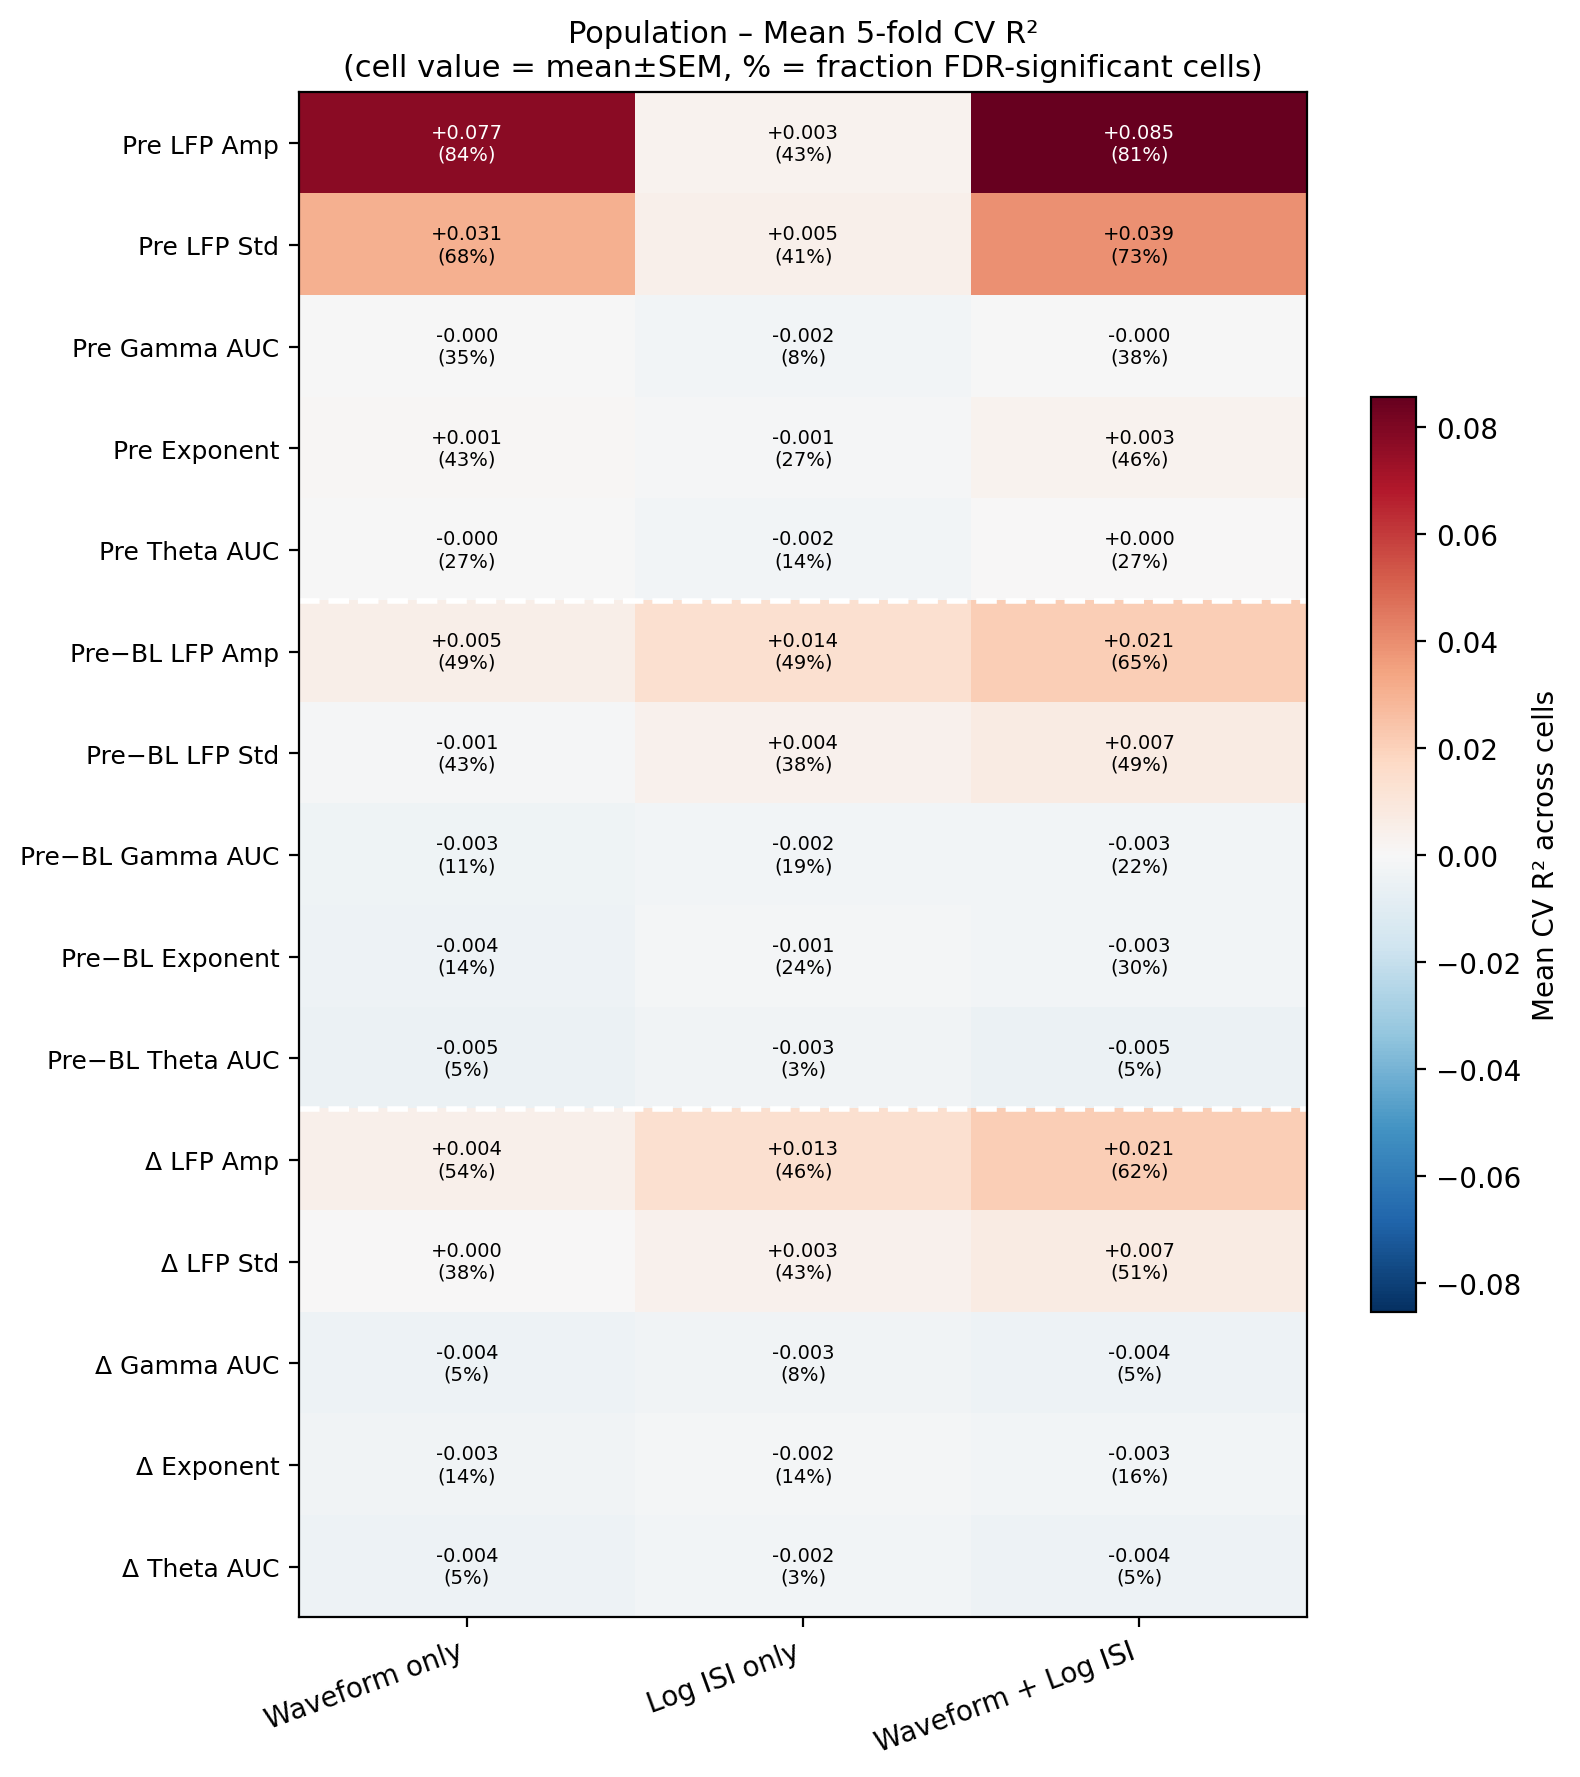

In [12]:
# ── Plot 1: Mean CV R² across cells ───────────────────────────────────────────
n_t = len(target_names)
n_p = len(predictor_sets)

mean_r2 = np.full((n_t, n_p), np.nan)
sem_r2  = np.full((n_t, n_p), np.nan)
frac_sig = np.full((n_t, n_p), np.nan)

for t_idx, tn in enumerate(target_names):
    for p_idx, pn in enumerate(predictor_sets):
        vals = r2_pop[tn][pn]
        valid = vals[np.isfinite(vals)]
        if len(valid) > 0:
            mean_r2[t_idx, p_idx]  = np.mean(valid)
            sem_r2[t_idx, p_idx]   = stats.sem(valid)
            frac_sig[t_idx, p_idx] = np.mean(sig_pop[tn][pn])

vmax = max(abs(np.nanmax(mean_r2)), abs(np.nanmin(mean_r2)), 0.005)

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(mean_r2, aspect='auto', vmin=-vmax, vmax=vmax, cmap='RdBu_r')
ax.set_xticks(range(n_p)); ax.set_xticklabels(predictor_sets, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(n_t)); ax.set_yticklabels(target_labels, fontsize=9)

for r in range(n_t):
    for c in range(n_p):
        v = mean_r2[r, c]
        fs = frac_sig[r, c]
        if np.isfinite(v):
            tc = 'white' if abs(v) > vmax * 0.6 else 'black'
            ax.text(c, r, f'{v:+.3f}\n({fs:.0%})', ha='center', va='center',
                    fontsize=7, color=tc)

for d in [4.5, 9.5]: ax.axhline(d, color='white', lw=2, ls='--')
plt.colorbar(im, ax=ax, label='Mean CV R² across cells', shrink=0.6)
ax.set_title('Population – Mean 5-fold CV R²\n(cell value = mean±SEM, % = fraction FDR-significant cells)', fontsize=11)
fig.tight_layout()
plt.show()

In [7]:
# ── Plot 2: Beta weight distributions — FDR-significant (target, feature) pairs
sig_pairs = df_tests[df_tests.sig_fdr][['target','target_label','feature']].values.tolist()

if not sig_pairs:
    print('No population-level FDR-significant (target, feature) pairs.')
else:
    ncols = min(len(sig_pairs), 5)
    nrows = math.ceil(len(sig_pairs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
    axes = np.array(axes).flatten() if len(sig_pairs) > 1 else [axes]
    fig.suptitle('Population Beta Weights — FDR-significant (target × feature)\n'
                 'One-sample t-test vs 0  |  Waveform only model', fontsize=11)

    for ax, (tn, tl, feat) in zip(axes, sig_pairs):
        betas = beta_pop[tn][feat]
        valid = betas[np.isfinite(betas)]
        row   = df_tests[(df_tests.target == tn) & (df_tests.feature == feat)].iloc[0]

        # Raincloud-style: strip + box
        ax.axvline(0, color='gray', lw=1, ls='--')
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(valid))
        ax.scatter(valid, jitter, alpha=0.6, s=20, color='#1976D2', zorder=3)
        ax.boxplot(valid, vert=False, positions=[0], widths=0.3,
                   patch_artist=True, medianprops=dict(color='k', lw=2),
                   boxprops=dict(facecolor='#1976D2', alpha=0.3),
                   whiskerprops=dict(color='k'), capprops=dict(color='k'),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
        ax.set_yticks([])
        ax.set_xlabel('β (std units)', fontsize=8)
        p_str = f'p_fdr={row.p_val_fdr:.3f}' if row.p_val_fdr >= 0.001 else 'p_fdr<0.001'
        ax.set_title(f'{tl}\n{feat}\nn={row.n}  {p_str}', fontsize=8)

    for i in range(len(sig_pairs), len(axes)): axes[i].set_visible(False)
    fig.tight_layout()
    plt.show()

No population-level FDR-significant (target, feature) pairs.


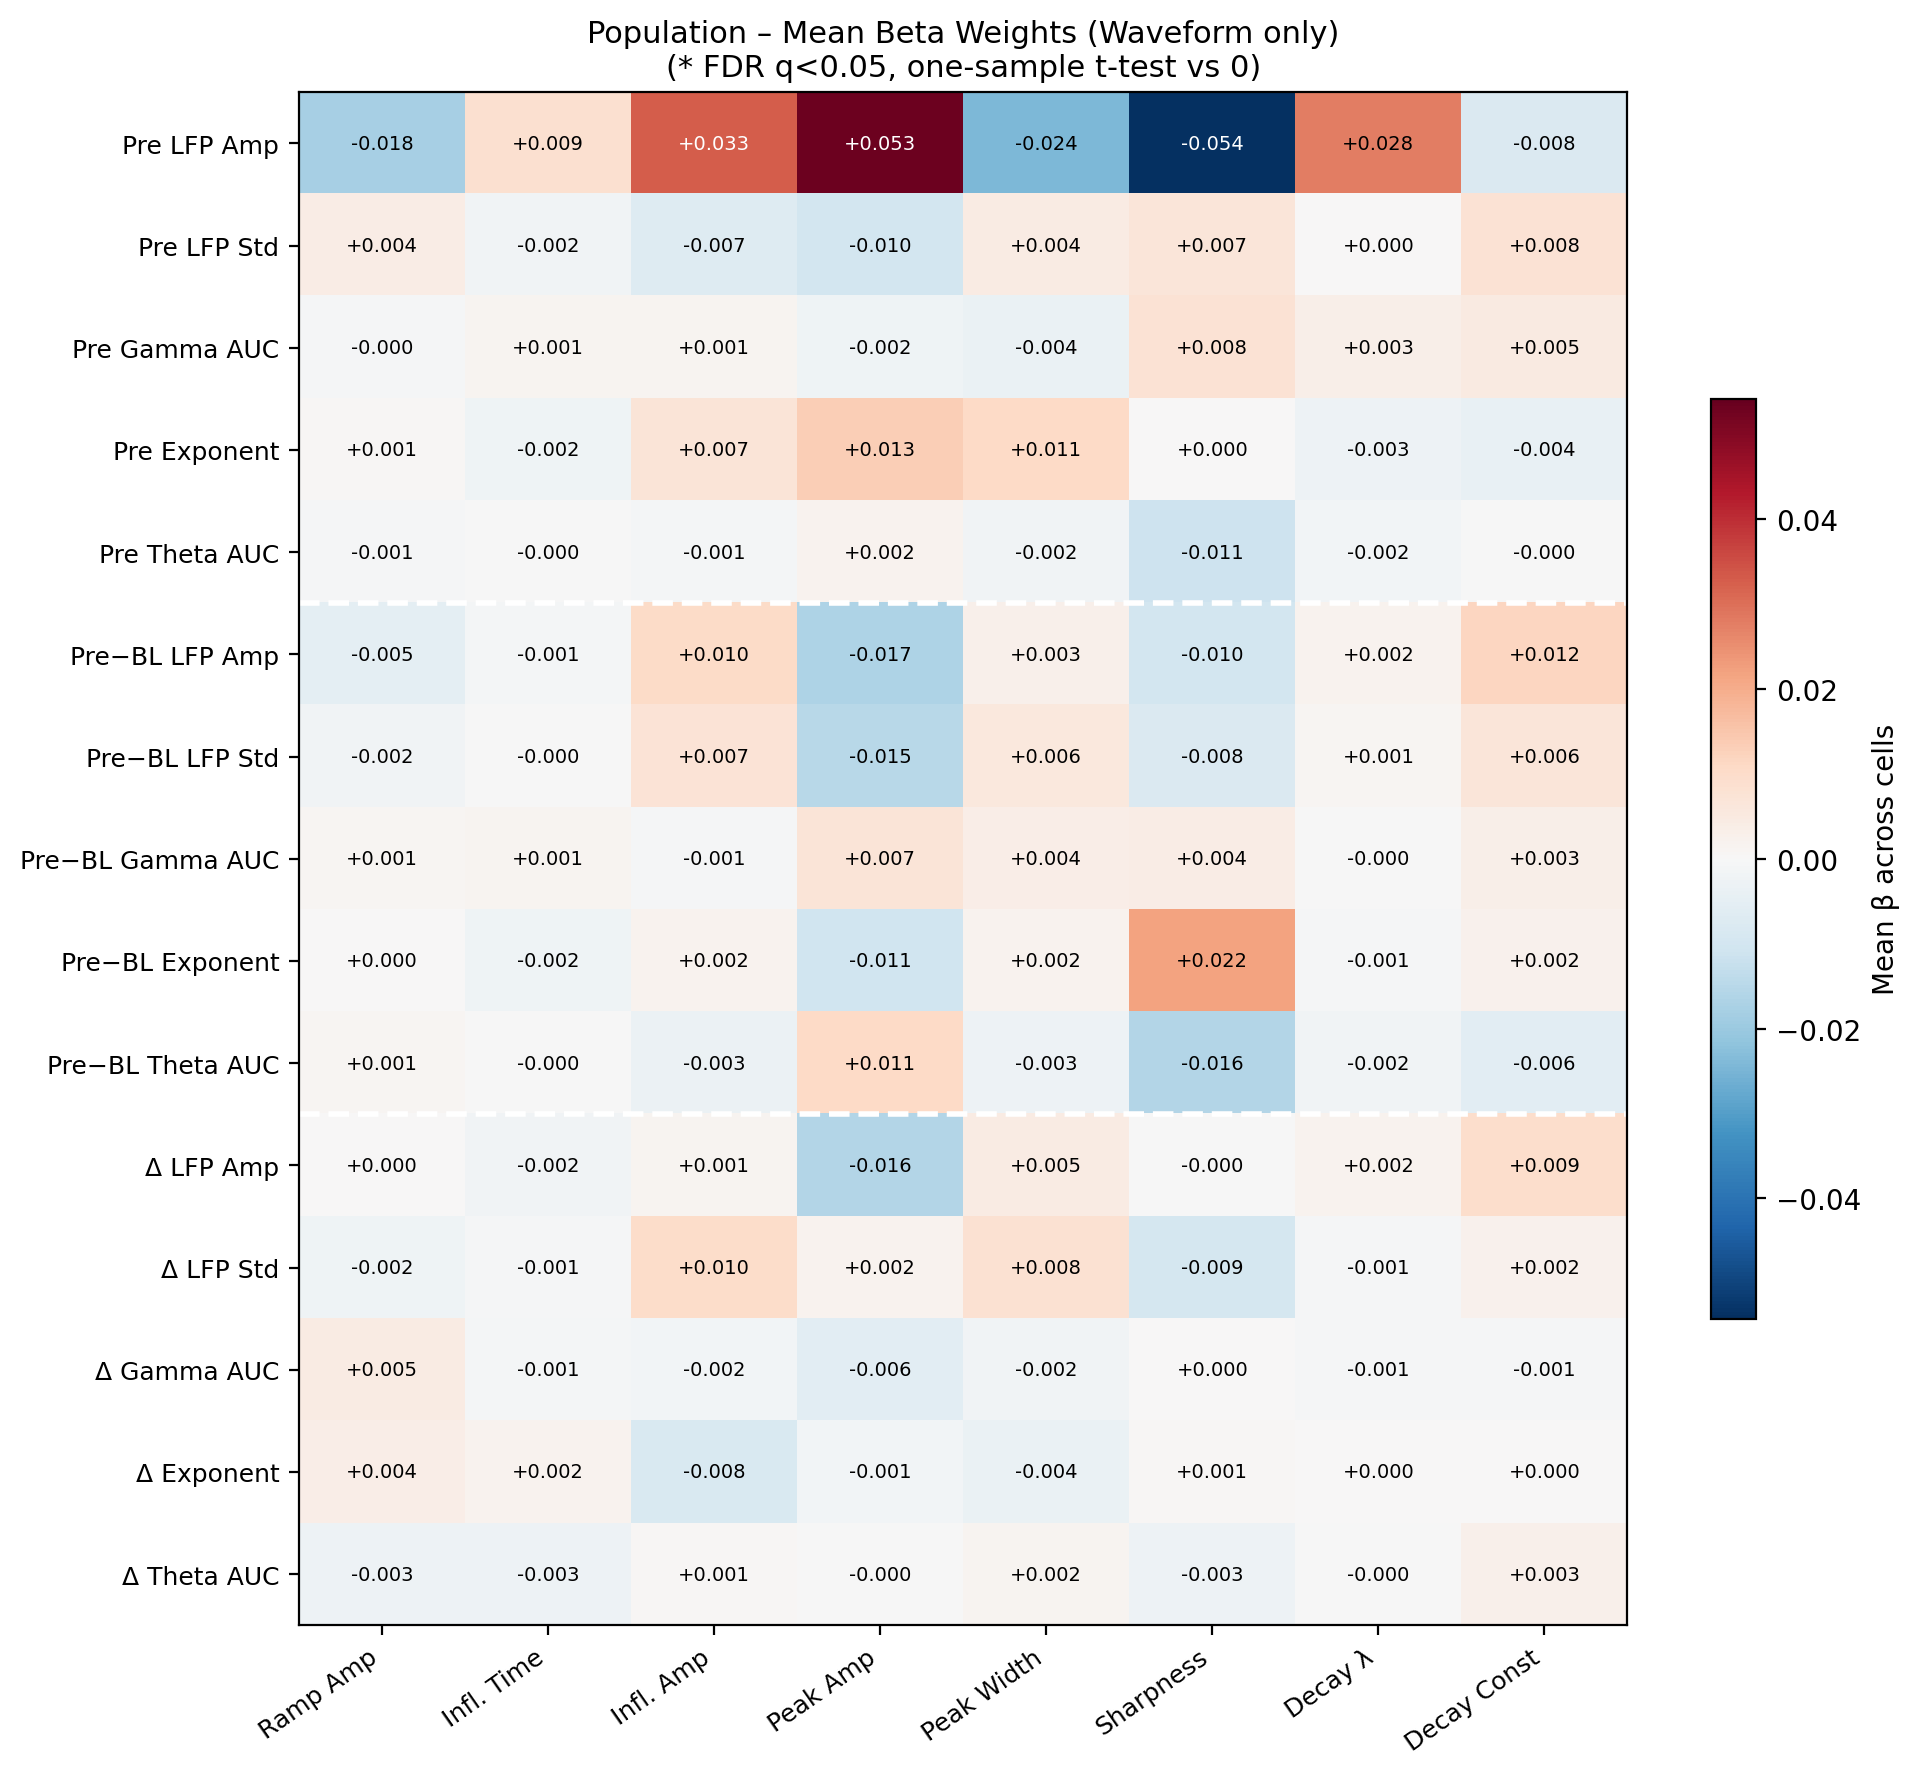

In [11]:
# ── Plot 3: All beta weights for a given LFP target (waveform features × target heatmap)
# Mean beta across cells, asterisks for population FDR significance

mean_beta_mat = np.full((len(target_names), len(waveform_labels)), np.nan)
sig_beta_mat  = np.zeros((len(target_names), len(waveform_labels)), dtype=bool)

for t_idx, tn in enumerate(target_names):
    for w_idx, wl in enumerate(waveform_labels):
        betas = beta_pop[tn][wl]
        valid = betas[np.isfinite(betas)]
        if len(valid) > 0:
            mean_beta_mat[t_idx, w_idx] = np.mean(valid)
        row = df_tests[(df_tests.target == tn) & (df_tests.feature == wl)]
        if not row.empty:
            sig_beta_mat[t_idx, w_idx] = bool(row.iloc[0]['sig_fdr'])

vmax = max(abs(np.nanmax(mean_beta_mat)), abs(np.nanmin(mean_beta_mat)), 0.01)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(mean_beta_mat, aspect='auto', vmin=-vmax, vmax=vmax, cmap='RdBu_r')
ax.set_xticks(range(len(waveform_labels)))
ax.set_xticklabels(waveform_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(target_names)))
ax.set_yticklabels(target_labels, fontsize=9)

for r in range(len(target_names)):
    for c in range(len(waveform_labels)):
        v = mean_beta_mat[r, c]
        if np.isfinite(v):
            star = '*' if sig_beta_mat[r, c] else ''
            tc   = 'white' if abs(v) > vmax * 0.6 else 'black'
            ax.text(c, r, f'{v:+.3f}{star}', ha='center', va='center',
                    fontsize=7, color=tc, fontweight='bold' if star else 'normal')

for d in [4.5, 9.5]: ax.axhline(d, color='white', lw=2, ls='--')
plt.colorbar(im, ax=ax, label='Mean β across cells', shrink=0.6)
ax.set_title('Population – Mean Beta Weights (Waveform only)\n(* FDR q<0.05, one-sample t-test vs 0)', fontsize=11)
fig.tight_layout()
plt.show()

In [9]:
# ── Save population results ────────────────────────────────────────────────────
pop_save_path = os.path.join(SPE1_PICKLE_ROOT, 'ridge_regression_pickles', 'population_ridge_results.pkl')

pop_results = dict(
    df_tests      = df_tests,
    mean_r2       = mean_r2,
    frac_sig      = frac_sig,
    mean_beta_mat = mean_beta_mat,
    sig_beta_mat  = sig_beta_mat,
    r2_pop        = r2_pop,
    beta_pop      = beta_pop,
    target_names  = target_names,
    target_labels = target_labels,
    predictor_sets= predictor_sets,
    waveform_labels = waveform_labels,
    cell_ids      = cell_ids,
)

with open(pop_save_path, 'wb') as f:
    pickle.dump(pop_results, f)
print(f'Saved: {os.path.basename(pop_save_path)}')
print(f'FDR-significant population results:')
print(df_tests[df_tests.sig_fdr][['target_label','feature','n','mean_beta','p_val_fdr']].to_string(index=False))

Saved: population_ridge_results.pkl
FDR-significant population results:
Empty DataFrame
Columns: [target_label, feature, n, mean_beta, p_val_fdr]
Index: []


In [ ]:
# ── Plot 4: Population scatter — pooled actual vs predicted across cells ────────
# Load each cell ONCE and compute predictions for all significant targets in one pass.

from ridge_regression_utils import (
    load_cell_data, build_ridge_matrices, get_predictions,
    WAVEFORM_LABELS, WAVEFORM_COLS,
)
from tqdm import tqdm as _tqdm

PRE_WIN      = (-0.055, -0.005)
POST_WIN     = ( 0.005,  0.055)
BASELINE_WIN = (-0.20,  -0.10)

# Accumulate (actual_z, pred_z) per target across cells
pooled = {tn: {'y': [], 'yp': [], 'colors': []} for tn in target_names}
cmap   = plt.cm.get_cmap('tab20', len(cell_ids))

for c_idx, cid in _tqdm(list(enumerate(cell_ids)), desc='Loading cells', unit='cell'):
    cell_num = int(cid.replace('c', ''))
    try:
        df_reg, sp, lfp_win = load_cell_data(cell_num)
    except Exception as e:
        print(f'  {cid}: skip ({e})')
        continue

    _, _, _, _, Y_cell, tnames_cell, _ = build_ridge_matrices(
        df_reg, sp, lfp_win, PRE_WIN, POST_WIN, BASELINE_WIN)

    X_wv = df_reg[WAVEFORM_COLS].values.astype(float)

    for tn in target_names:
        cell_res = all_results.get(cid, {}).get(tn, {}).get('Waveform only', {})
        if not cell_res.get('sig_fdr', False):
            continue
        best_alpha = cell_res.get('best_alpha')
        if best_alpha is None or not np.isfinite(best_alpha):
            continue
        if tn not in tnames_cell:
            continue

        t_col = tnames_cell.index(tn)
        y_z, yp_z = get_predictions(Y_cell[:, t_col], X_wv, best_alpha)
        if y_z is None:
            continue

        pooled[tn]['y'].extend(y_z.tolist())
        pooled[tn]['yp'].extend(yp_z.tolist())
        pooled[tn]['colors'].extend([cmap(c_idx)] * len(y_z))

# ── Plot ──
sig_targets_wv = [
    (tn, tl) for tn, tl in zip(target_names, target_labels)
    if len(pooled[tn]['y']) > 0
]

if not sig_targets_wv:
    print('No significant targets found after pooling.')
else:
    ncols = min(len(sig_targets_wv), 5)
    nrows = math.ceil(len(sig_targets_wv) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = np.array(axes).flatten() if len(sig_targets_wv) > 1 else [axes]
    fig.suptitle('Population – Actual vs Predicted (Waveform only, z-scored within cell)\n'
                 'Pooled across cells with FDR-significant model', fontsize=11)

    for ax, (tn, tl) in zip(axes, sig_targets_wv):
        y   = np.array(pooled[tn]['y'])
        yp  = np.array(pooled[tn]['yp'])
        col = pooled[tn]['colors']
        r2  = float(np.corrcoef(y, yp)[0, 1] ** 2)

        ax.scatter(y, yp, c=col, alpha=0.08, s=2, rasterized=True)
        lo, hi = min(y.min(), yp.min()), max(y.max(), yp.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_xlabel('Actual (z)', fontsize=8)
        ax.set_ylabel('Predicted (z)', fontsize=8)
        ax.set_title(f'{tl}\nPooled r²={r2:.3f}  ({len(y):,} spikes)', fontsize=8)

    for i in range(len(sig_targets_wv), len(axes)):
        axes[i].set_visible(False)

    fig.tight_layout()
    plt.show()